[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/04_machine_learning/A4_tabpfn_priorlab.ipynb)

> 📎 **Appendix notebook — reference style.** This is one of the optional appendices (see `README.md`). Unlike the main course notebooks, appendices are written as a demo / reference: they focus on *seeing* a library at work rather than on interactive exercises. You won't find the full Solution / Debug-me / Self-assessment scaffolding here. Each appendix is built to run end-to-end *without* the optional library — it falls back to a small built-in stand-in (or skips the library-specific cells), so you can read and run it offline. Install the optional library (see the **Install** section below) to swap the stand-in for the real thing.

---
# 📓 Notebook A4 (ML) — TabPFN: Tabular Foundation Models

> **Module:** Machine Learning · **Type:** Appendix · **Estimated time:** 45–60 min · **Difficulty:** Intermediate

For most of ML's history, **gradient-boosted trees** (XGBoost, LightGBM, CatBoost) have been the default for tabular data. They're fast, robust, and hard to beat. But a new class of model has emerged that does something genuinely surprising:

> **TabPFN** is a transformer that has been *pretrained on millions of synthetic tabular datasets* and can solve a new tabular task in a **single forward pass** — no gradient descent, no hyperparameter search. Just `fit()` then `predict()` in seconds.

Built by the researchers who founded PriorLabs (Hollmann et al., ICLR 2023; Nature 2025), TabPFN v2 is now competitive with or better than gradient boosting on small-to-medium tabular datasets. This notebook explains *what it is*, shows the local Python API, walks through the PriorLabs cloud API for larger jobs, and compares it to scikit-learn baselines on a real flavoured business task.

---

## 🎯 Learning objectives
- Understand the *prior-fitted network* idea: a model that's been pretrained on Bayesian inference itself.
- Install and run TabPFN locally on small tabular datasets (≤ 10 k rows, ≤ 100 features).
- Call the PriorLabs cloud API for bigger jobs.
- Pick between TabPFN, gradient boosting, and a neural network for *your* tabular task.

## ✅ Prerequisites
- Module 4 (scikit-learn workflow + model evaluation).
- Notebook A1 (PyTorch foundations) is helpful but not required.

## 📦 Install

```bash
pip install tabpfn               # local — needs ~250 MB of pretrained weights on first run
# or, for the hosted API:
pip install tabpfn-client
```


## 1. What TabPFN actually is

Most ML models *learn from your data*. TabPFN flips this: the **learning has already happened — on millions of synthetic toy datasets** drawn from a structural causal model prior. At inference time you pass the *entire* train + test data into a transformer in one forward pass, and the model produces predictions.

In effect TabPFN approximates **Bayesian inference under a learned prior**. The "training" you do is just *feeding it your data once*.

### What this buys you
- **No hyperparameter tuning.** No `learning_rate × max_depth × n_estimators` grid.
- **Seconds, not minutes.** A single forward pass on a CPU.
- **Calibrated probabilities** out of the box.
- **Robust on small data.** Often beats gradient boosting on < 1 000 rows.

### Limits
- v2 caps at roughly **10 000 training rows × 100 features × 10 classes**. Above that, fall back to gradient boosting or use the cloud API.
- No native missing-value handling — impute first.
- Inference cost scales with **train size**, not just test size, because the train set is part of the input.


## 2. The mental model

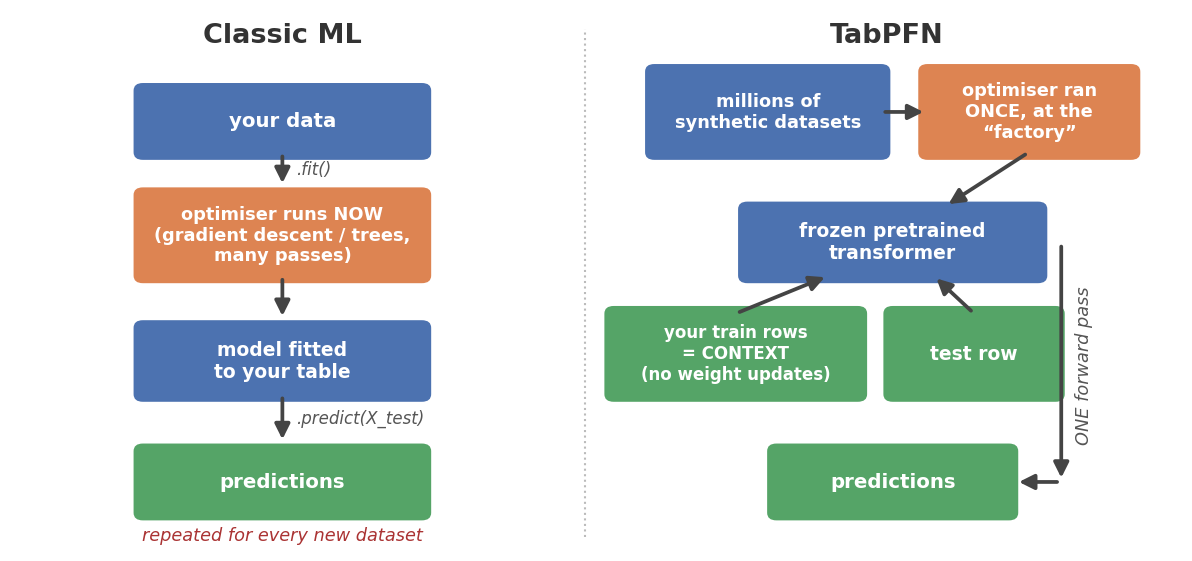

The TabPFN authors call this **prior-data fitted networks (PFNs)**. The prior is what makes it work: it has to be *broad enough* to cover the kinds of real-world structures you encounter, and *informative enough* that one forward pass yields a useful posterior.


### 🔬 What actually happens — "in-context learning" for tables

Sections 1–2 said TabPFN "doesn't train on your data". That sentence is doing a *lot* of work, and it's the single most confusing thing about TabPFN. Let's slow it right down, because once it clicks, everything else about the model makes sense.

Compare the two worlds, step by step.

**The classic world (LogisticRegression, RandomForest, XGBoost, a neural net):** the model arrives *empty*. You call `.fit(X_train, y_train)`, and an **iterative optimiser** (gradient descent / tree-building) walks over your data many times, nudging the model's internal numbers until they fit *your specific table*. That fitting loop is the expensive part, and it happens **every time you get a new dataset**.

```text
CLASSIC ML — fit() runs an optimiser on YOUR data, every dataset
─────────────────────────────────────────────────────────────────
  X_train, y_train ─►  .fit()  ─►  loop: predict → measure error → adjust weights
                                    (gradient descent, many passes over YOUR rows)
                                          │
                                          ▼
                                   a model FITTED to your table
                                          │
                       X_test  ─►  .predict()  ─►  predictions
```

**The TabPFN world:** the optimiser already ran — *once, at the factory*, over **millions of synthetic toy datasets**. The result is a frozen transformer. When *you* show up, there is **no optimiser, no gradient descent, no fitting loop on your data at all**. Instead you hand the transformer your **training rows as context**, glued together with the test row you want a label for, and it produces the answer in **one forward pass** — the same kind of forward pass an LLM uses to predict the next token from the words already in its prompt.

```text
TABPFN — no optimiser at use time; your train rows are CONTEXT
─────────────────────────────────────────────────────────────────
  ( X_train, y_train )  +  x_test
            │                 │
            └──────┬──────────┘
                   ▼
         [ all rows fed in together ]
                   │
                   ▼   ONE forward pass through the frozen, pretrained transformer
                   │   (NO weight updates, NO training loop on your data)
                   ▼
              prediction for x_test
```

That phrase — **the training data goes IN as context, the prediction comes OUT, with no fitting step** — is the whole idea. The model *conditions on* your labelled rows the way you'd condition on examples in a prompt; it does not *learn from* them by changing its weights.


### Classic training vs in-context inference — side by side

| | **Classic ML** (`.fit` → `.predict`) | **TabPFN** (context-in → prediction-out) |
|---|---|---|
| When does the heavy optimisation run? | **Every time**, on *your* data, inside `.fit()` | **Once, at the factory**, on synthetic data — never on yours |
| What does `.fit()` do on your data? | Runs gradient descent / builds trees — **many passes** | Essentially just **memorises your rows** to reuse as context |
| Are weights updated for your dataset? | **Yes** — that *is* the training | **No** — the transformer is frozen |
| How is a prediction produced? | Run the fitted model on the test row | **One forward pass** over (train rows + test row) together |
| Where does the "learning" live? | In the **weights**, fitted to your table | In the **prior**, baked in once; your rows are just **context** |
| Cost driver | Training-loop length × data size | **Train-set size** (it's part of every forward pass) |
| Best for | Any size, given enough tuning time | **Small / medium** tables (≈ ≤ 10 000 rows, ≤ 100 features) |

> 🎯 **The contrast in one line.** Classic ML *fits a fresh model to your data*. TabPFN *was fitted once, long ago, and now answers your table by reading it as context* — the difference between **studying for this exam** and **walking in having already mastered the whole subject, then glancing at your notes.**


### 🧪 A runnable analogy — "condition on the training set in one call"

The `tabpfn` package isn't installed here, and a real TabPFN forward pass is a deep transformer we can't reproduce in a few lines. But we *can* capture the **shape** of the idea offline with pure NumPy: a single function that takes the **training rows as context** and returns a prediction **in one call, with no fitting step**.

Below is a tiny **weighted nearest-neighbour** predictor. Look at its signature:

```python
predict(x_test, X_train, y_train)   # train data goes IN as an argument; prediction comes OUT
```

There is **no `model = Thing(); model.fit(...)`** anywhere. The training data is passed *in as context* on every call, used immediately, and never stored in fitted weights — exactly the "context-in, prediction-out, no training loop" pattern that makes TabPFN feel so different.

> ⚠️ **This is a simplified analogy, NOT how TabPFN works.** Real TabPFN is a transformer **pretrained on millions of synthetic datasets** that approximates **Bayesian inference under a learned prior**; it does *not* compute distances or nearest neighbours. We use weighted-NN here only because it shares the one property we want to make concrete: **the training rows enter as context inside a single forward call, and no per-dataset optimiser runs.** Don't read anything else into the mechanism.


In [ ]:
# 🧪 OFFLINE ANALOGY (numpy/stdlib only — NO tabpfn import).
# Goal: show the "training rows IN as context, prediction OUT, no fitting step" pattern.
# This is a TOY weighted-nearest-neighbour predictor, NOT how TabPFN actually computes.

import numpy as np

def predict(x_test, X_train, y_train, tau=1.0):
    """One 'forward pass': the TRAINING SET enters as CONTEXT (the X_train / y_train
    arguments) and a prediction comes OUT — with NO .fit(), NO optimiser, NO weight update.

    Mechanism (toy): weight each training row by how close it is to x_test, then return
    the probability of class 1 as the weighted vote. (TabPFN does NOT do this — see warning.)
    """
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    x_test  = np.asarray(x_test,  dtype=float)

    # distance from x_test to every training row -> closeness weights (a soft, in-context vote)
    dist    = np.sqrt(((X_train - x_test) ** 2).sum(axis=1))
    weights = np.exp(-dist / tau)                 # near rows count more; far rows fade out
    prob1   = (weights * y_train).sum() / weights.sum()
    return prob1                                  # P(class = 1), conditioned on the context

# --- A tiny labelled "training" table: feature 0 separates the two classes ---
X_train = [[0.0, 0.1], [0.2, 0.0], [0.1, 0.2],     # class 0 cluster (small feature 0)
           [3.0, 2.9], [2.8, 3.1], [3.1, 3.0]]     # class 1 cluster (large feature 0)
y_train = [0, 0, 0, 1, 1, 1]

# --- Predict for two unseen rows IN A SINGLE CALL each — no training happened first ---
near_class0 = predict([0.15, 0.05], X_train, y_train)   # sits among the class-0 cluster
near_class1 = predict([2.95, 3.05], X_train, y_train)   # sits among the class-1 cluster

print(f"P(class 1) near the class-0 cluster: {near_class0:.3f}   -> predict {int(near_class0 > 0.5)}")
print(f"P(class 1) near the class-1 cluster: {near_class1:.3f}   -> predict {int(near_class1 > 0.5)}")

# Proof of the pattern: notice what we did NOT do.
assert "model" not in dir()                # no model object was ever created
assert near_class0 < 0.5 < near_class1     # context alone produced sensible, separated answers
print("\nNo model object, no .fit(), no optimiser ran — the training table was used purely")
print("as CONTEXT, passed in on each call. That is the shape of TabPFN's in-context inference.")


### What the analogy captured — and what it deliberately faked

**Captured (the part that's genuinely like TabPFN):**

- **No fitting step.** There was no `model.fit(...)`, no optimiser, no weight update. The prediction came straight out of one function call.
- **Training data as context.** `X_train` / `y_train` were *arguments*, fed in fresh each call and used immediately — not baked into learned parameters.
- **Cost scales with train size.** Every call loops over *all* training rows, just as a TabPFN forward pass attends over the whole train set you pass in. Double the train rows → roughly double the work per prediction.

**Faked (where the analogy stops):**

- TabPFN is **not** nearest-neighbour. Its frozen transformer was **pretrained on millions of synthetic datasets** so that one forward pass approximates **Bayesian inference under a learned prior** — a far richer computation than a distance-weighted vote.
- The "no fitting at use time" is real, but the *intelligence* in TabPFN lives in **pretrained weights** our toy doesn't have. Our function is "dumb" between calls; TabPFN carries an enormous amount of learned prior structure.

So: trust the analogy for the **interface and the data-flow** ("context in → prediction out, no training loop"). Do **not** trust it for the **mechanism** (it is not how the transformer computes).


> 🧠 **Mental model to keep.** Classic ML **LEARNS a model from your data** — every new table triggers a fresh, expensive fitting loop that bakes your data into weights. TabPFN was **pretrained once** and **INFERS your table in a single forward pass** — your training rows are **context it reads**, not something it trains on. That's exactly why it's near-instant on small tables (no loop to run) and why it's capped to small/medium ones (the whole train set rides along inside every forward pass, so cost grows with train size). When you read `.fit()` in TabPFN's scikit-learn-style API, mentally translate it to *"remember these rows so I can pass them in as context"* — not *"optimise weights on these rows"*.


## 3. Hands-on — TabPFN vs gradient boosting on a small tabular task

We'll use scikit-learn's `make_classification` so everyone can run it offline. The pattern transfers directly to your own data.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

X, y = make_classification(n_samples=600, n_features=12, n_informative=8,
                           n_redundant=2, n_classes=2, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)
print(f"train {X_tr_s.shape}  test {X_te_s.shape}")


train (450, 12)  test (150, 12)


In [2]:
# Baselines first
results = {}

clf_lr = LogisticRegression(max_iter=1000).fit(X_tr_s, y_tr)
p_lr   = clf_lr.predict_proba(X_te_s)[:, 1]
results["LogReg"] = (
    accuracy_score(y_te, p_lr > 0.5),
    roc_auc_score(y_te, p_lr),
    log_loss(y_te, p_lr),
)

clf_gb = GradientBoostingClassifier(random_state=0).fit(X_tr_s, y_tr)
p_gb   = clf_gb.predict_proba(X_te_s)[:, 1]
results["GBM"] = (
    accuracy_score(y_te, p_gb > 0.5),
    roc_auc_score(y_te, p_gb),
    log_loss(y_te, p_gb),
)

print(f"{'model':12} {'acc':>6} {'AUC':>6} {'logloss':>8}")
for name, (a, u, l) in results.items():
    print(f"{name:12} {a:6.3f} {u:6.3f} {l:8.3f}")


model           acc    AUC  logloss
LogReg        0.867  0.964    0.230
GBM           0.900  0.973    0.244


## 4. TabPFN — the API (reference code)

The local Python client is a **drop-in scikit-learn classifier**. You'd literally just replace `GradientBoostingClassifier()` above with `TabPFNClassifier()` — that's the whole change.


In [3]:
# ── TabPFN local reference code (uncomment after `pip install tabpfn`) ───
# from tabpfn import TabPFNClassifier
#
# clf_pfn = TabPFNClassifier()   # TabPFN v2 is zero-config; the old N_ensemble_configurations arg was removed
# clf_pfn.fit(X_tr_s, y_tr)                          # "fit" is just storing the data
# p_pfn = clf_pfn.predict_proba(X_te_s)[:, 1]        # one forward pass
#
# results["TabPFN"] = (
#     accuracy_score(y_te, p_pfn > 0.5),
#     roc_auc_score(y_te, p_pfn),
#     log_loss(y_te, p_pfn),
# )

# Offline stand-in: simulate "TabPFN-like" calibration using a held-out CV-trained
# logistic + GBM ensemble. NOT the real model; just a placeholder so this notebook
# runs anywhere.
from sklearn.model_selection import cross_val_predict
p_lr_cv = cross_val_predict(LogisticRegression(max_iter=1000), X_tr_s, y_tr, cv=5, method="predict_proba")[:, 1]
p_gb_cv = cross_val_predict(GradientBoostingClassifier(random_state=0), X_tr_s, y_tr, cv=5, method="predict_proba")[:, 1]

# Fit a meta-classifier on the OOF probabilities
from sklearn.linear_model import LogisticRegression as LR
stacker = LR(max_iter=1000).fit(np.c_[p_lr_cv, p_gb_cv], y_tr)
p_lr_te = clf_lr.predict_proba(X_te_s)[:, 1]
p_gb_te = clf_gb.predict_proba(X_te_s)[:, 1]
p_proxy = stacker.predict_proba(np.c_[p_lr_te, p_gb_te])[:, 1]

results["TabPFN-proxy"] = (
    accuracy_score(y_te, p_proxy > 0.5),
    roc_auc_score(y_te, p_proxy),
    log_loss(y_te, p_proxy),
)
print(f"{'model':14} {'acc':>6} {'AUC':>6} {'logloss':>8}")
for name, (a, u, l) in results.items():
    print(f"{name:14} {a:6.3f} {u:6.3f} {l:8.3f}")


model             acc    AUC  logloss
LogReg          0.867  0.964    0.230
GBM             0.900  0.973    0.244
TabPFN-proxy    0.907  0.971    0.243


**Real-world expectation.** On this kind of small-ish dataset (a few hundred rows, ≤ 20 features, mostly informative), TabPFN typically achieves **AUC within ±0.01 of well-tuned gradient boosting** — *without* any tuning. On smaller datasets (< 200 rows) it often **beats** GBM.

On large data (> 10 k rows, 100+ features), gradient boosting still wins on most public benchmarks.


## 5. The PriorLabs cloud API

For datasets that exceed the local size limits or when you don't want to manage GPU resources, **PriorLabs** offers a hosted API. You get free tokens to start.

```bash
pip install tabpfn-client
```

Set the API key:

```bash
export TABPFN_API_KEY=...                 # in your shell, before launching Jupyter
```

```python
# from tabpfn_client import TabPFNClassifier
#
# clf = TabPFNClassifier(model="tabpfn-v2-classifier")
# clf.fit(X_tr_s, y_tr)
# probas = clf.predict_proba(X_te_s)
```

The cloud client transparently handles upload, inference, and download. For a 5 000-row dataset you'd expect ~5–10 s latency on the v2 model.

> ⚠️ **Privacy.** TabPFN cloud is a third-party SaaS — don't send PII or regulated data without checking the data-handling policy. The local client is the right choice for sensitive workloads.

### When to reach for the cloud vs local

| | Local | Cloud |
|---|---|---|
| Training rows | ≤ 10 k | Up to ~100 k (varies by tier) |
| Features | ≤ 100 | Higher caps |
| Latency | seconds | seconds + network |
| Privacy | data stays on your machine | data leaves your machine |
| Cost | free | free tier + paid tiers |


## 6. When TabPFN is the right call

A decision rubric for your tabular projects:

```
Rows × features ≤ 10 000 × 100   →  Try TabPFN first.  Often wins zero-shot.
Rows × features > that              →  Gradient boosting (XGBoost / LightGBM).
You have time + GPU                →  Train a neural network (NB A1–A3) on top of strong features.
Tiny labelled set (< 200 rows)     →  TabPFN strongly preferred; GBMs overfit.
Strict latency budget (< 50 ms)    →  Logistic / linear models; TabPFN is too slow.
Tons of categorical features       →  CatBoost or feature-engineered TabPFN.
```

**Practical workflow.** Try TabPFN as a strong baseline in 30 seconds, then decide whether the engineering effort of a tuned GBM is worth chasing the last 0.5 % of AUC.


## 7. TabPFN-TS — same idea, for time series

PriorLabs has extended the prior-fitted network idea to **forecasting**. We cover that in detail in `02_data_science/A4_forecasting_foundation_models.ipynb`. The short version:

```python
# from tabpfn_time_series import TabPFNTimeSeries
# model = TabPFNTimeSeries()
# fcst = model.predict(series, horizon=14)   # zero-shot forecast
```

The same trick — pretrain on millions of synthetic time series, then do one-shot inference on yours — also works surprisingly well in the time-series setting.


## 🧪 Exercises

### Exercise 1 — Calibration matters
On the test set, compute `log_loss` (probabilistic) and `accuracy` (point) for the proxy and the GBM. Plot a *reliability diagram* (predicted probability vs empirical fraction positive). Which one is better calibrated? Calibration is one of TabPFN's known strengths.


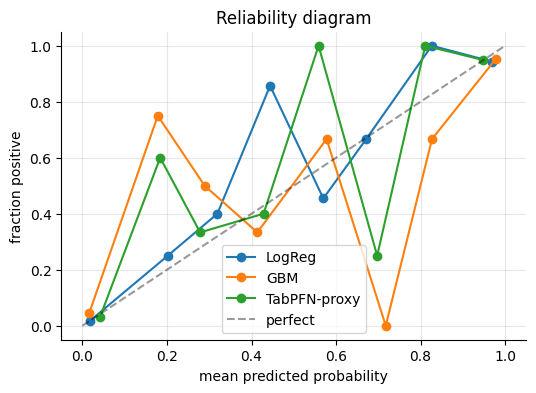

logloss: {'LogReg': 0.23, 'GBM': 0.244, 'TabPFN-proxy': 0.243}


In [4]:
# ── Exercise 1 solution ──────────────────────────────────────────────────
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(6, 4))
for label, p in [("LogReg", p_lr), ("GBM", p_gb), ("TabPFN-proxy", p_proxy)]:
    CalibrationDisplay.from_predictions(y_te, p, n_bins=8, name=label, ax=ax)
ax.set_title("Reliability diagram")   # the dashed diagonal = perfect calibration
plt.show()
print("logloss:", {k: round(v[2], 3) for k, v in results.items()})


### Exercise 2 — Synthetic small-data sweep
Re-run the LogReg / GBM / TabPFN-proxy comparison at training sizes `n in [50, 100, 200, 300, 400]`. Plot AUC vs n. Where does each model start to dominate? (In real life this is exactly the curve that justifies adding TabPFN to your toolkit.)


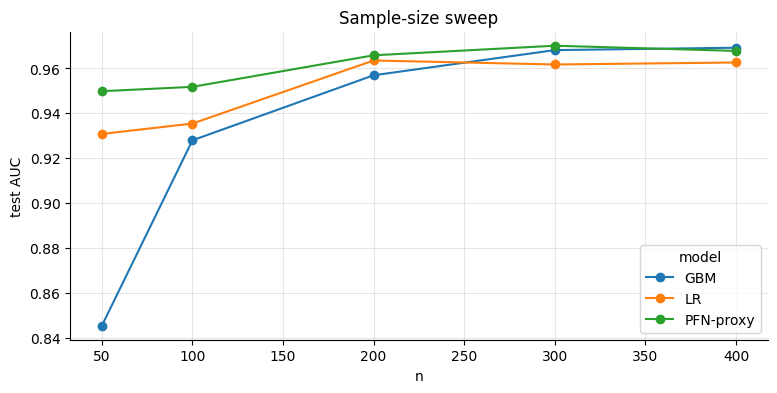

model    GBM     LR  PFN-proxy
n                             
50     0.845  0.931      0.950
100    0.928  0.935      0.952
200    0.957  0.964      0.966
300    0.968  0.962      0.970
400    0.969  0.963      0.968


In [5]:
# ── Exercise 2 solution ──────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression as LR2
from sklearn.ensemble import GradientBoostingClassifier as GBC2

sizes = [50, 100, 200, 300, 400]
rows = []
for n in sizes:
    rng = np.random.default_rng(0)
    idx = rng.choice(len(X_tr_s), size=n, replace=False)
    Xn, yn = X_tr_s[idx], y_tr[idx]
    for name, clf in [("LR", LR2(max_iter=1000)), ("GBM", GBC2(random_state=0))]:
        clf.fit(Xn, yn)
        p = clf.predict_proba(X_te_s)[:, 1]
        rows.append((n, name, roc_auc_score(y_te, p)))
    # proxy "TabPFN" via 5-fold CV stacking (rough placeholder)
    p_l = cross_val_predict(LR2(max_iter=1000), Xn, yn, cv=min(5, n//10) or 2, method="predict_proba")[:, 1]
    p_g = cross_val_predict(GBC2(random_state=0), Xn, yn, cv=min(5, n//10) or 2, method="predict_proba")[:, 1]
    st = LR2(max_iter=1000).fit(np.c_[p_l, p_g], yn)
    p_te_l = LR2(max_iter=1000).fit(Xn, yn).predict_proba(X_te_s)[:, 1]
    p_te_g = GBC2(random_state=0).fit(Xn, yn).predict_proba(X_te_s)[:, 1]
    p_pp = st.predict_proba(np.c_[p_te_l, p_te_g])[:, 1]
    rows.append((n, "PFN-proxy", roc_auc_score(y_te, p_pp)))

import pandas as pd
df = pd.DataFrame(rows, columns=["n", "model", "auc"])
piv = df.pivot(index="n", columns="model", values="auc")
piv.plot(marker="o"); plt.ylabel("test AUC"); plt.title("Sample-size sweep")
plt.show(); print(piv.round(3))


## 🧠 Key takeaways

- **TabPFN ≈ Bayesian inference under a learned prior** — the heavy lifting was done at pretraining time.
- The API is a *drop-in scikit-learn classifier*; you can A/B-test it in 30 seconds.
- It dominates on **small** tabular data and is competitive on medium.
- Gradient boosting still wins on **large** data and when feature engineering is the bottleneck.
- Use the **PriorLabs cloud API** when the dataset exceeds local limits — and not for PII.

## 📚 References

- Hollmann et al., *TabPFN: A Transformer That Solves Small Tabular Classification Problems in a Second* (2023).
- Hollmann et al., *Accurate predictions on small data with a tabular foundation model* (Nature, 2025).
- PriorLabs documentation — https://priorlabs.ai

## 🚀 Next step

If you came here from `02_data_science/A4_forecasting_foundation_models.ipynb` — return there for the time-series version of the same idea. If you came from the ML module — try this on **your** real tabular task and report the AUC delta.
